# PCA + KMeans and Hierarchical Clustering

This notebook loads the cleaned waveform data, performs PCA dimensionality reduction, evaluates candidate cluster numbers, runs KMeans and hierarchical clustering, compares the resulting waveform families, and exports cluster-assigned CSV files.

**Data structure:** rows = neuron responses; columns = time samples; voltage values are in mV; sampling rate = 30,000 Hz.


In [1]:
# Imports

import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score

plt.rcParams["figure.figsize"] = (12, 6)
plt.style.use("default")

In [2]:
# Load cleaned data

filepath = "../data/spike_waveforms_clean.csv"

df = pd.read_csv(
    filepath,
    header=None
)

sampling_rate_hz = 30000
time_ms = np.arange(df.shape[1]) / sampling_rate_hz * 1000

print("Data shape:", df.shape)
print("Rows = neuron responses:", df.shape[0])
print("Columns = time samples:", df.shape[1])
print("Waveform duration (ms):", time_ms[-1])

Data shape: (26862, 62)
Rows = neuron responses: 26862
Columns = time samples: 62
Waveform duration (ms): 2.033333333333333


## PCA

PCA transforms each waveform from the original time-sample space into a smaller set of components that capture the strongest patterns of variation across waveforms. For this dataset, PCA helps reduce the 62 time samples into fewer dimensions before clustering. PC1 and PC2 are also useful for visualizing whether waveforms form separable groups.


In [3]:
# Standardize before PCA

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (26862, 62)


PCs needed for 90% variance: 6
PCs needed for 95% variance: 9


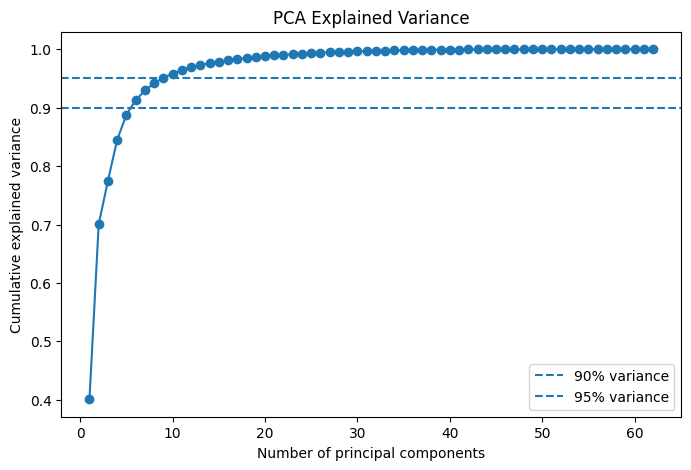

In [4]:
# PCA explained variance

pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance)

n_pcs_90 = np.argmax(cumulative_explained_variance >= 0.90) + 1
n_pcs_95 = np.argmax(cumulative_explained_variance >= 0.95) + 1

print("PCs needed for 90% variance:", n_pcs_90)
print("PCs needed for 95% variance:", n_pcs_95)

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_explained_variance) + 1),
    cumulative_explained_variance,
    marker="o"
)

plt.axhline(0.90, linestyle="--", label="90% variance")
plt.axhline(0.95, linestyle="--", label="95% variance")

plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Explained Variance")
plt.legend()
plt.show()

In [5]:
# PCA representation used for clustering

n_pcs_for_clustering = n_pcs_95

pca = PCA(
    n_components=n_pcs_for_clustering
)

X_pca = pca.fit_transform(X_scaled)

print("PCA data used for clustering:", X_pca.shape)

PCA data used for clustering: (26862, 9)


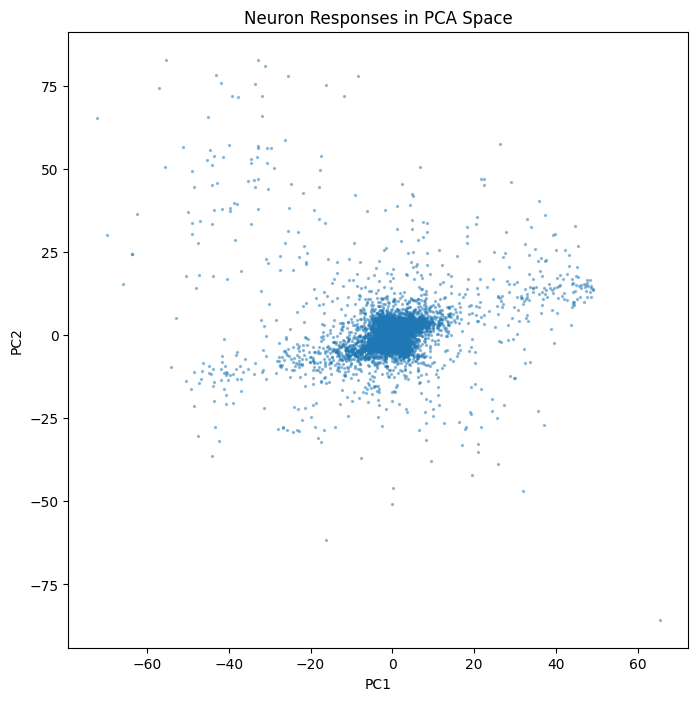

In [6]:
# PCA visualization using first two PCs

plt.figure(figsize=(8, 8))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    s=2,
    alpha=0.4
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Neuron Responses in PCA Space")
plt.show()

## KMeans clustering

This section evaluates several possible cluster counts using silhouette score and inertia, then runs KMeans using the selected number of clusters.


Best k by silhouette score: 2


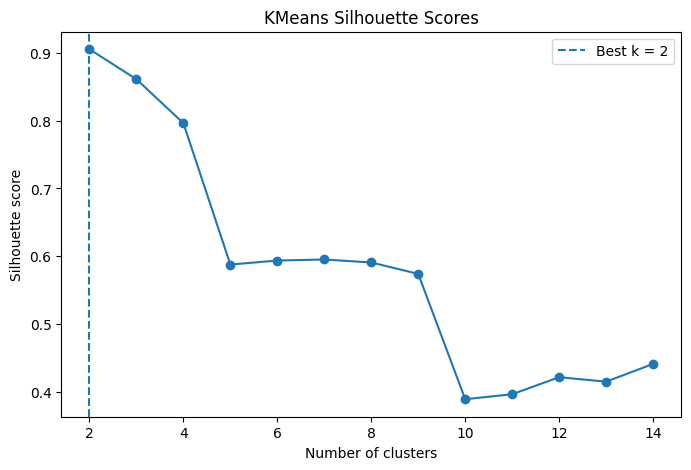

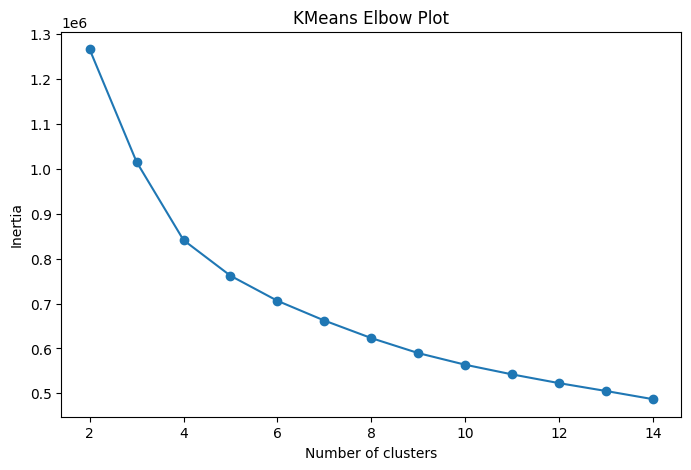

In [7]:
# Evaluate KMeans cluster numbers

cluster_range = range(2, 15)

sil_scores = []
inertia_values = []

for candidate_k in cluster_range:

    km_test = KMeans(
        n_clusters=candidate_k,
        random_state=42,
        n_init=10
    )

    candidate_labels = km_test.fit_predict(X_pca)

    sil_scores.append(
        silhouette_score(X_pca, candidate_labels)
    )

    inertia_values.append(
        km_test.inertia_
    )

best_k = list(cluster_range)[
    np.argmax(sil_scores)
]

print("Best k by silhouette score:", best_k)

plt.figure(figsize=(8, 5))

plt.plot(
    cluster_range,
    sil_scores,
    marker="o"
)

plt.axvline(
    best_k,
    linestyle="--",
    label=f"Best k = {best_k}"
)

plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.title("KMeans Silhouette Scores")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    cluster_range,
    inertia_values,
    marker="o"
)

plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("KMeans Elbow Plot")
plt.show()

In [8]:
# Select cluster number

# Use the silhouette-based value by default.
# If you specifically want to test 7 clusters, replace best_k with 7.
k = best_k

print("Selected k:", k)

Selected k: 2


In [9]:
# Shared plotting and export helper functions

def plot_pca_clusters(X_pca_values, labels, title):
    plt.figure(figsize=(8, 8))

    plt.scatter(
        X_pca_values[:, 0],
        X_pca_values[:, 1],
        c=labels,
        cmap="tab10",
        s=2,
        alpha=0.5
    )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title)
    plt.colorbar(label="Cluster")
    plt.show()


def plot_mean_waveforms_by_cluster(df_values, labels, title):
    labels = np.asarray(labels)
    cluster_ids = sorted(np.unique(labels))

    plt.figure(figsize=(12, 8))

    for cluster_id in cluster_ids:

        cluster_waveforms = df_values.loc[
            labels == cluster_id
        ]

        mean_waveform = cluster_waveforms.mean(axis=0)

        plt.plot(
            time_ms,
            mean_waveform,
            linewidth=2,
            label=f"Cluster {cluster_id}"
        )

    plt.xlabel("Time (ms)")
    plt.ylabel("Voltage (mV)")
    plt.title(title)
    plt.legend()
    plt.show()


def export_clustered_csv(df_values, labels, cluster_column, output_path):
    clustered_df = df_values.copy()

    clustered_df.insert(
        0,
        cluster_column,
        labels
    )

    clustered_df.insert(
        1,
        "original_row",
        df_values.index
    )

    clustered_df = clustered_df.sort_values(
        [cluster_column, "original_row"]
    )

    clustered_df.to_csv(
        output_path,
        index=False
    )

    print("Saved:", output_path)

    return clustered_df

In [10]:
# Run KMeans clustering

kmeans_model = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

labels_kmeans = kmeans_model.fit_predict(X_pca) + 1

print("KMeans cluster counts:")
display(
    pd.Series(labels_kmeans).value_counts().sort_index()
)

KMeans cluster counts:


1    26759
2      103
Name: count, dtype: int64

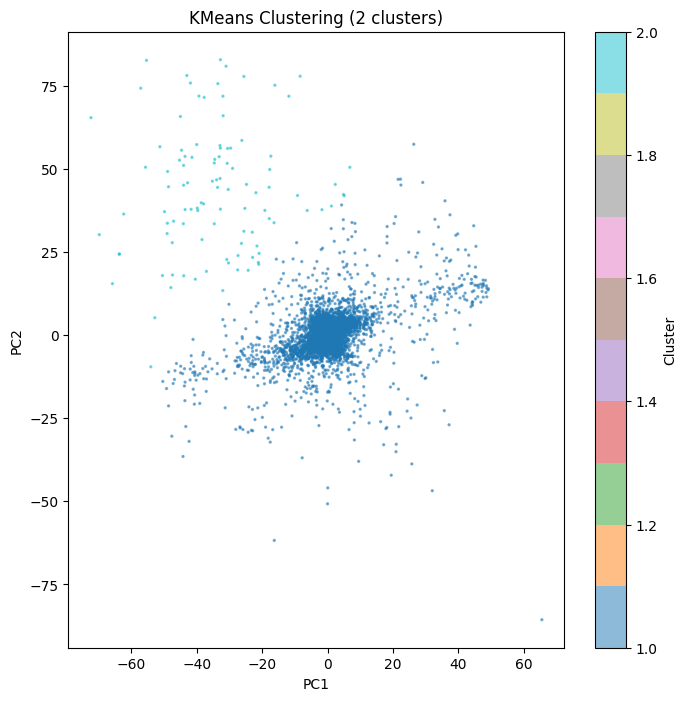

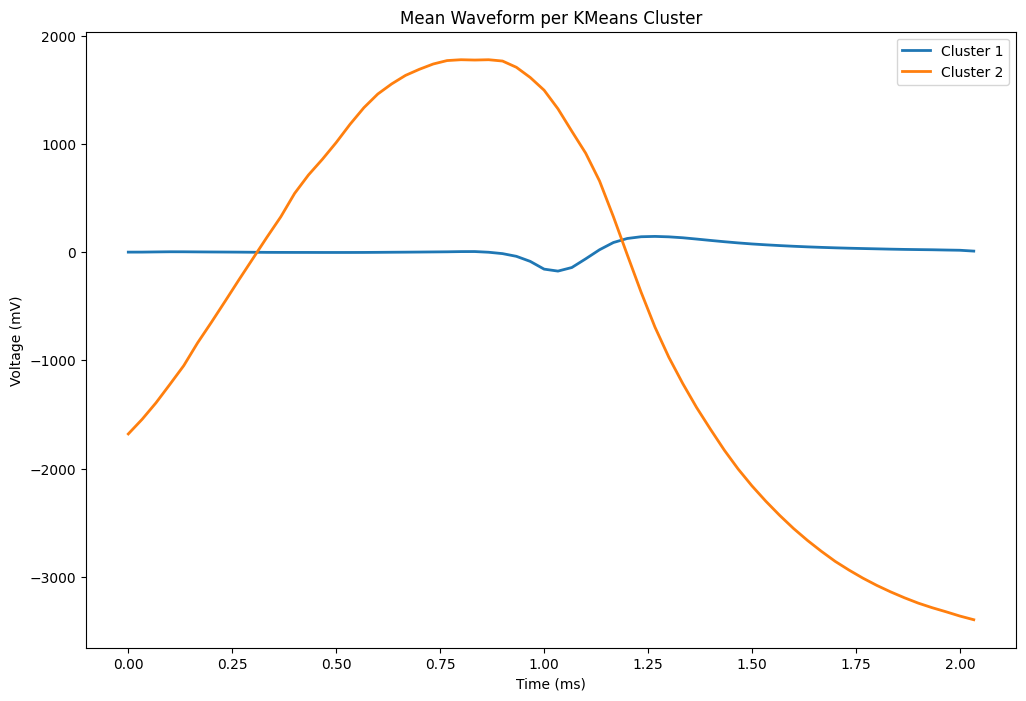

In [11]:
# Plot KMeans clusters

plot_pca_clusters(
    X_pca,
    labels_kmeans,
    f"KMeans Clustering ({k} clusters)"
)

plot_mean_waveforms_by_cluster(
    df,
    labels_kmeans,
    "Mean Waveform per KMeans Cluster"
)

## Hierarchical clustering

This section runs agglomerative hierarchical clustering on the same PCA-reduced data, using the same number of clusters selected above. Unlike the earlier sampled dendrogram approach, this assigns a hierarchical cluster label to every row.


In [12]:
# Run hierarchical clustering on all rows

hierarchical_model = AgglomerativeClustering(
    n_clusters=k,
    linkage="ward"
)

labels_hierarchical = hierarchical_model.fit_predict(X_pca) + 1

print("Hierarchical cluster counts:")
display(
    pd.Series(labels_hierarchical).value_counts().sort_index()
)

Hierarchical cluster counts:


1    26767
2       95
Name: count, dtype: int64

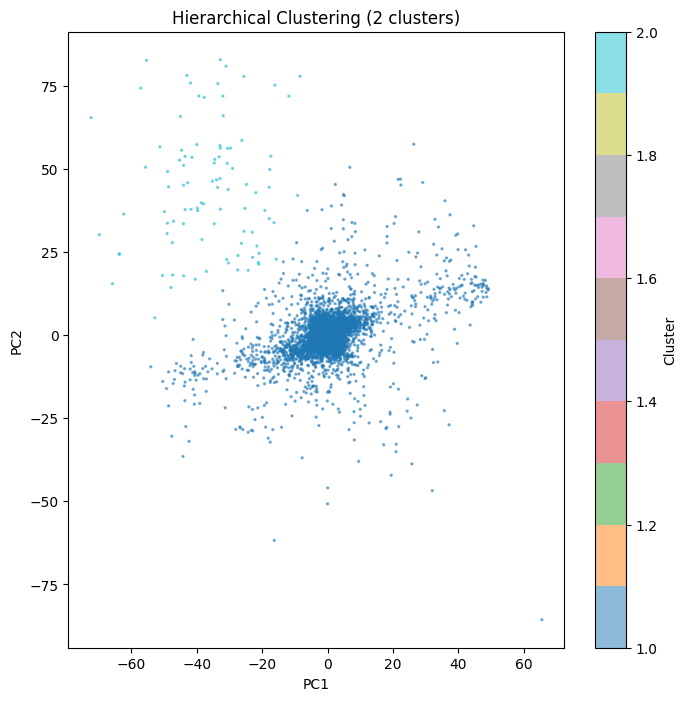

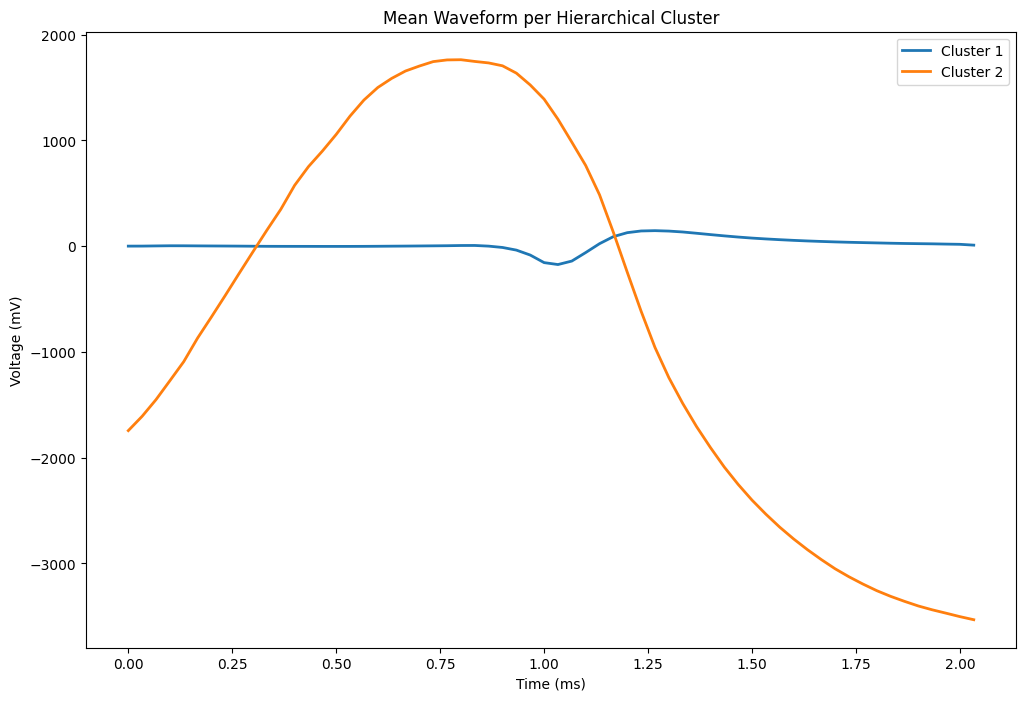

In [13]:
# Plot hierarchical clusters

plot_pca_clusters(
    X_pca,
    labels_hierarchical,
    f"Hierarchical Clustering ({k} clusters)"
)

plot_mean_waveforms_by_cluster(
    df,
    labels_hierarchical,
    "Mean Waveform per Hierarchical Cluster"
)

## Compare KMeans and hierarchical cluster assignments

The adjusted Rand index compares two cluster labelings. A value near 1 means the two methods assign rows to highly similar groups. A value near 0 means agreement is close to chance.


In [14]:
# Compare clustering methods

ari = adjusted_rand_score(
    labels_kmeans,
    labels_hierarchical
)

print("Adjusted Rand Index between KMeans and hierarchical labels:", ari)

cluster_assignments = pd.DataFrame({
    "original_row": df.index,
    "kmeans_cluster": labels_kmeans,
    "hierarchical_cluster": labels_hierarchical
})

display(
    cluster_assignments.head()
)

Adjusted Rand Index between KMeans and hierarchical labels: 0.9489523999430222


,original_row,kmeans_cluster,hierarchical_cluster
0,0,1,1
1,1,1,1
2,2,1,1
3,3,1,1
4,4,1,1


## Export cluster assignments and sorted clustered datasets

These CSV files preserve the original waveform values, add cluster assignments, and sort rows so that rows from the same cluster are consecutive.


In [15]:
# Export clustered CSV files

os.makedirs(
    "../outputs",
    exist_ok=True
)

df_kmeans_sorted = export_clustered_csv(
    df,
    labels_kmeans,
    "kmeans_cluster",
    "../outputs/spike_waveforms_kmeans_clustered_sorted.csv"
)

df_hierarchical_sorted = export_clustered_csv(
    df,
    labels_hierarchical,
    "hierarchical_cluster",
    "../outputs/spike_waveforms_hierarchical_clustered_sorted.csv"
)

cluster_assignments.to_csv(
    "../outputs/cluster_assignments.csv",
    index=False
)

print("Saved: ../outputs/cluster_assignments.csv")

Saved: ../outputs/spike_waveforms_kmeans_clustered_sorted.csv
Saved: ../outputs/spike_waveforms_hierarchical_clustered_sorted.csv
Saved: ../outputs/cluster_assignments.csv
